# **Online Shoppers Purchasing Intention**

---

# **STAGE 3 - Modeling and Evaluation**

## **0. Load Dataset**
---

In [ ]:


import pandas as pd 
import numpy as np                    
import seaborn as sns                  
import matplotlib.pyplot as plt       
from matplotlib import rcParams

import warnings                       
warnings.filterwarnings("ignore")

In [ ]:


url = 'https://drive.google.com/file/d/1yaOIhMEWflXgfEbcBUUnYW3Y4Wdz8pYI/view?usp=share_link'
file_id = url.split('/')[-2]
dwn_url = 'https://drive.google.com/uc?id=' + file_id


df = pd.read_csv(dwn_url)

## **1. Feature Selection**
---

**data Selected **

In [ ]:
df_selection=df[['ProductRelated', 'Duration per Page Administrative', 'Duration per Page Informational','ExitRates', 'PageValues',
                 'Revenue_True', 'VisitorType_Returning_Visitor', 'SpecialDay']]

In [ ]:
df_selection.columns

Index(['ProductRelated', 'Duration per Page Administrative',
       'Duration per Page Informational', 'ExitRates', 'PageValues',
       'Revenue_True', 'VisitorType_Returning_Visitor', 'SpecialDay'],
      dtype='object')

In [ ]:

X = df_selection.drop(columns='Revenue_True').copy()
                      
y = df_selection['Revenue_True'].copy()

## **2. Split Dataset**
---

In [ ]:
import sys
print(sys.executable)

In [ ]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [ ]:

from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
#**The training dataset was oversampled usingSMOTE**


In [ ]:
from imblearn import under_sampling, over_sampling
X_train, y_train = over_sampling.SMOTE(sampling_strategy=0.5).fit_resample(X_train, y_train)
print('SMOTE')
print(pd.Series(y_train).value_counts())

SMOTE
Revenue_True
0    7181
1    3590
Name: count, dtype: int64


## **3. Modeling**
---

In [ ]:


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_validate

def eval_classification(model):
    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    y_pred_proba = model.predict_proba(X_test)
    y_pred_proba_train = model.predict_proba(X_train)
    
    print("Accuracy (Test Set): %.2f" % accuracy_score(y_test, y_pred))
    print("Accuracy (Train Set): %.2f" % accuracy_score(y_train, y_pred_train))
    print("Precision (Test Set): %.2f" % precision_score(y_test, y_pred))
    print("Precision (Train Set): %.2f" % precision_score(y_train, y_pred_train))
    print("Recall (Test Set): %.2f" % recall_score(y_test, y_pred))
    print("Recall (Train Set): %.2f" % recall_score(y_train, y_pred_train))
    print("F1-Score (Test Set): %.2f" % f1_score(y_test, y_pred))
    print("F1-Score (Train Set): %.2f" % f1_score(y_train, y_pred_train))
    
    print("roc_auc (test-proba): %.2f" % roc_auc_score(y_test, y_pred_proba[:, 1]))
    print("roc_auc (train-proba): %.2f" % roc_auc_score(y_train, y_pred_proba_train[:, 1]))
    
    score = cross_validate(model, X_train, y_train, cv=5, scoring='roc_auc', return_train_score=True)
    print('roc_auc (crossval test): '+ str(score['test_score'].mean()))
    print('roc_auc (crossval train): '+ str(score['train_score'].mean()))

def show_feature_importance(model):
    feat_importances = pd.Series(model.feature_importances_, index=X.columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(10, 8))
    ax.invert_yaxis()

    plt.xlabel('score')
    plt.ylabel('feature')
    plt.title('feature importance score')

def show_best_hyperparameter(model):
    print(model.best_estimator_.get_params())

**Confusion Matrix Function**

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def c_matrix (model) :
  y_pred = model.predict(X_test)
  cf_matrix = confusion_matrix(y_test, y_pred)

  # mengatur matrix
  fig = plt.figure(figsize = (8,5))
  group_names = ['TRUE NEGATIF','FALSE POSITIF','FALSE NEGATIF','TRUE POSITIF']
  group_counts = ['{0:0.0f}'.format(value) for value in
                  cf_matrix.flatten()]
  group_percentages = ['{0:.2%}'.format(value) for value in
                      cf_matrix.flatten()/np.sum(cf_matrix)]
  labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in
            zip(group_names,group_counts,group_percentages)]
  labels = np.asarray(labels).reshape(2,2)

  # display matrix
  sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='coolwarm', annot_kws={'size': 15})

### **A ) Logistic Regression**

#### **Fit Model Logistic Regression**

In [ ]:
# logistic regression

from sklearn.linear_model import LogisticRegression 
logreg = LogisticRegression()
logreg.fit(X_train, y_train) 
eval_classification(logreg)

Accuracy (Test Set): 0.88
Accuracy (Train Set): 0.86
Precision (Test Set): 0.56
Precision (Train Set): 0.79
Recall (Test Set): 0.79
Recall (Train Set): 0.79
F1-Score (Test Set): 0.65
F1-Score (Train Set): 0.79
roc_auc (test-proba): 0.89
roc_auc (train-proba): 0.89
roc_auc (crossval test): 0.8902073278534897
roc_auc (crossval train): 0.890859115019756


#### **Confussion Matrix Logistic Regression**

Text(0.5, 1.0, 'Logistic Regression')

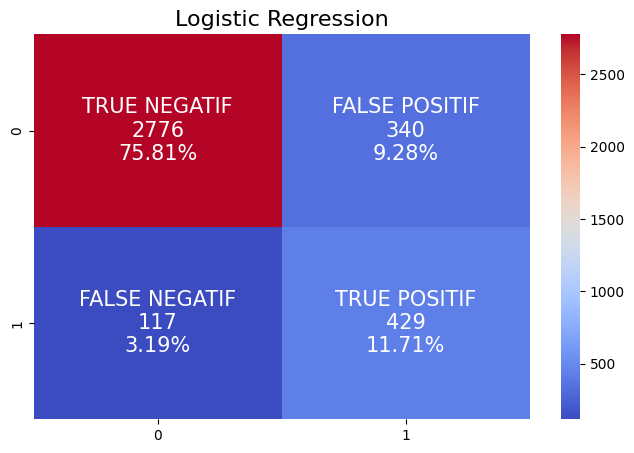

In [ ]:
c_matrix(logreg)
plt.title('Logistic Regression', fontsize=16)

#### **Hyperparameter Tuning Logistic Regression**

In [ ]:
# hyperparameter tuning

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

penalty = ['l1', 'l2']
C = [float(x) for x in np.linspace(0.0001, 0.05, 100)]
hyperparameters = dict(penalty=penalty, C=C)

logreg = LogisticRegression()
logreg_tuned = RandomizedSearchCV(logreg, hyperparameters, scoring='roc_auc', random_state=42, cv=5, n_iter=50)
logreg_tuned.fit(X_train, y_train)
eval_classification(logreg_tuned)


Accuracy (Test Set): 0.88
Accuracy (Train Set): 0.86
Precision (Test Set): 0.56
Precision (Train Set): 0.79
Recall (Test Set): 0.79
Recall (Train Set): 0.79
F1-Score (Test Set): 0.65
F1-Score (Train Set): 0.79
roc_auc (test-proba): 0.89
roc_auc (train-proba): 0.89
roc_auc (crossval test): 0.8895224623981781
roc_auc (crossval train): 0.8902069716529951


#### **Confussion Matrix Hyperparameter Tuning Logistic Regression**

Text(0.5, 1.0, 'Logistic Regression - Tuning')

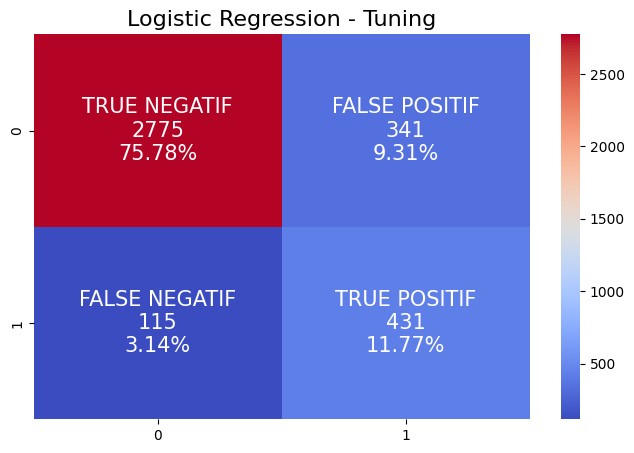

In [ ]:
c_matrix(logreg_tuned)
plt.title('Logistic Regression - Tuning', fontsize=16)

#### **Learning Curve Logistic Regression**

param value: 0.0001; train: 0.8767028746161237; test: 0.8787990731989448
param value: 0.0006040404040404041; train: 0.8821075346230517; test: 0.8836758288780112
param value: 0.0011080808080808082; train: 0.8840714761446855; test: 0.8854526677857871
param value: 0.0016121212121212123; train: 0.8851429743997138; test: 0.8865265297389817
param value: 0.002116161616161616; train: 0.8858701719447676; test: 0.8872741774699413
param value: 0.0026202020202020205; train: 0.886409121253509; test: 0.8878219822539463
param value: 0.0031242424242424243; train: 0.8868383722287885; test: 0.8883145363408522
param value: 0.003628282828282828; train: 0.887127164340749; test: 0.8886960012601861
param value: 0.004132323232323233; train: 0.88741234897569; test: 0.8890680618055458
param value: 0.004636363636363637; train: 0.8876419474324655; test: 0.8893642995857374
param value: 0.0051404040404040416; train: 0.8878497846568959; test: 0.8895858901475077
param value: 0.005644444444444445; train: 0.88796243103

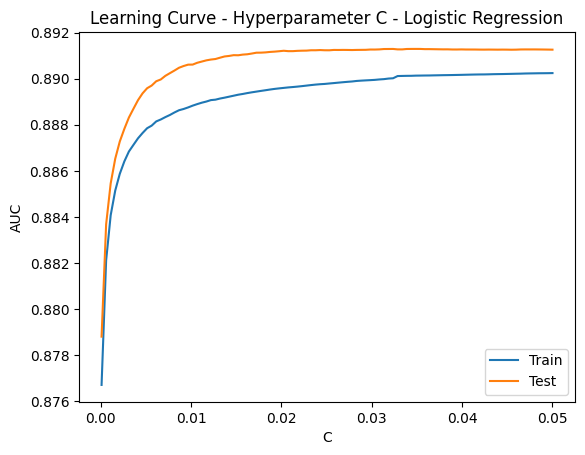

In [ ]:
# learning curve
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

def draw_learning_curve(param_values):
    train_scores = []
    test_scores = []

    for c in param_values:
        model = LogisticRegression(penalty='l2', C=c)
        model.fit(X_train, y_train)

        # eval on train
        y_pred_train_proba = model.predict_proba(X_train)
        train_auc = roc_auc_score(y_train, y_pred_train_proba[:,1])
        train_scores.append(train_auc)

        # eval on test
        y_pred_proba = model.predict_proba(X_test)
        test_auc = roc_auc_score(y_test, y_pred_proba[:,1])
        test_scores.append(test_auc)

        print('param value: ' + str(c) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc))

    plt.plot(param_values, train_scores, label='Train')
    plt.plot(param_values, test_scores, label='Test')
    plt.xlabel('C')
    plt.ylabel('AUC')
    plt.title('Learning Curve - Hyperparameter C - Logistic Regression')
    plt.legend()
    plt.show()

param_values = [float(x) for x in np.linspace(0.0001, 0.05, 100)]
draw_learning_curve(param_values)

### **B ) KNN**

#### **Fit Model KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
eval_classification(knn)

Accuracy (Test Set): 0.86
Accuracy (Train Set): 0.91
Precision (Test Set): 0.52
Precision (Train Set): 0.84
Recall (Test Set): 0.73
Recall (Train Set): 0.91
F1-Score (Test Set): 0.61
F1-Score (Train Set): 0.88
roc_auc (test-proba): 0.86
roc_auc (train-proba): 0.97
roc_auc (crossval test): 0.9290347777675422
roc_auc (crossval train): 0.9716003205664606


#### **Confussion Matrix KNN**

Text(0.5, 1.0, 'KNN')

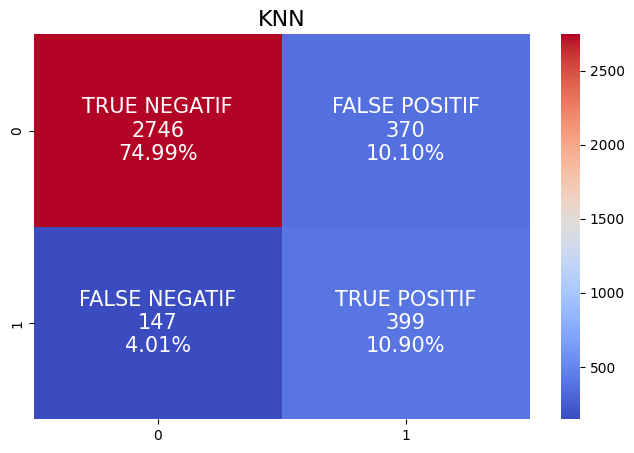

In [ ]:
c_matrix(knn)
plt.title('KNN', fontsize=16)

#### **Hyperparameter Tuning KNN**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

n_neighbors = list(range(1,30))
p=[1,2]
algorithm = ['auto', 'ball_tree', 'kd_tree', 'brute']
hyperparameters = dict(n_neighbors=n_neighbors, p=p, algorithm=algorithm)

knn.fit(X_train, y_train)
knn_tuned = RandomizedSearchCV(knn, hyperparameters, scoring='roc_auc', random_state=42, cv=5)
knn_tuned.fit(X_train, y_train)
eval_classification(knn_tuned)

Accuracy (Test Set): 0.87
Accuracy (Train Set): 0.91
Precision (Test Set): 0.56
Precision (Train Set): 0.87
Recall (Test Set): 0.66
Recall (Train Set): 0.85
F1-Score (Test Set): 0.61
F1-Score (Train Set): 0.86
roc_auc (test-proba): 0.87
roc_auc (train-proba): 0.97
roc_auc (crossval test): 0.9299600040219869
roc_auc (crossval train): 0.9648201942210097


#### **Confussion Matrix Hyperparameter Tuning KNN**

Text(0.5, 1.0, 'KNN - Tuning')

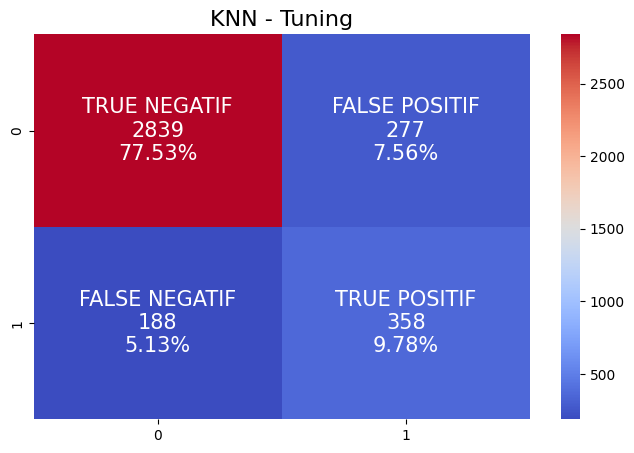

In [ ]:
c_matrix(knn_tuned)
plt.title('KNN - Tuning', fontsize=16)

#### **Learning Curve KNN**

param value: 100; train: 0.9163966424862268; test: 0.9126771548947415
param value: 101; train: 0.9162036230706302; test: 0.9128196899377901
param value: 102; train: 0.9160196611376588; test: 0.9127086007702183
param value: 103; train: 0.9159243345271625; test: 0.9129622249808387
param value: 104; train: 0.915658816460491; test: 0.9128896349692243
param value: 105; train: 0.9154576123389678; test: 0.9132040937239909
param value: 106; train: 0.9151829398144826; test: 0.9132378906929612
param value: 107; train: 0.9150307663483682; test: 0.9132446500867555
param value: 108; train: 0.9146472876621572; test: 0.9131600107209862
param value: 109; train: 0.9144520572122582; test: 0.9134327375662421
param value: 110; train: 0.9143817502004477; test: 0.9134297986993751
param value: 111; train: 0.9142363649975427; test: 0.9132196697183861
param value: 112; train: 0.9142328544957117; test: 0.9132234902453131
param value: 113; train: 0.9139897376976305; test: 0.9130359905391997
param value: 114; tra

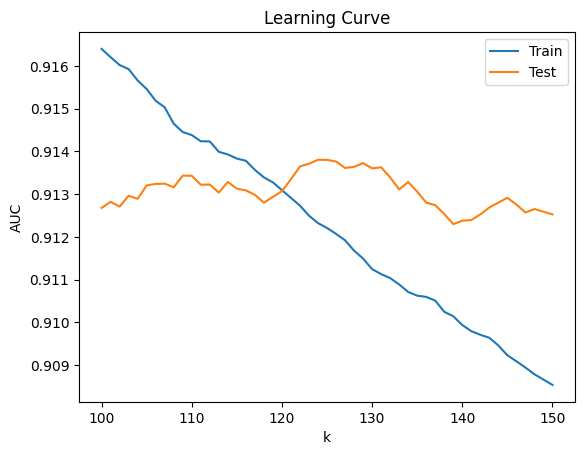

In [ ]:
# Analyzing Learning Curve
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

def draw_learning_curve(param_values):
    train_scores = []
    test_scores = []

    for i in param_values:
        model = KNeighborsClassifier(n_neighbors=i)
        model.fit(X_train, y_train)

        # eval on train
        y_pred_train_proba = model.predict_proba(X_train)
        train_auc = roc_auc_score(y_train, y_pred_train_proba[:,1])
        train_scores.append(train_auc)

        # eval on test
        y_pred_proba = model.predict_proba(X_test)
        test_auc = roc_auc_score(y_test, y_pred_proba[:,1])
        test_scores.append(test_auc)

        print('param value: ' + str(i) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc))

    plt.plot(param_values, train_scores, label='Train')
    plt.plot(param_values, test_scores, label='Test')
    plt.xlabel('k')
    plt.ylabel('AUC')
    plt.title('Learning Curve')
    plt.legend()
    plt.show()

param_values = [int(x) for x in np.linspace(100, 150, 50)]
draw_learning_curve(param_values)

### **C ) Decision Tree**

#### **Fit Model Decision Tree**

In [ ]:
# Fit Model Descision tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
eval_classification(dt)

Accuracy (Test Set): 0.84
Accuracy (Train Set): 1.00
Precision (Test Set): 0.46
Precision (Train Set): 1.00
Recall (Test Set): 0.59
Recall (Train Set): 0.99
F1-Score (Test Set): 0.52
F1-Score (Train Set): 1.00
roc_auc (test-proba): 0.72
roc_auc (train-proba): 1.00
roc_auc (crossval test): 0.8328912066887701
roc_auc (crossval train): 0.9999458825387624


#### **Confussion Matrix**

Text(0.5, 1.0, 'Descision Tree')

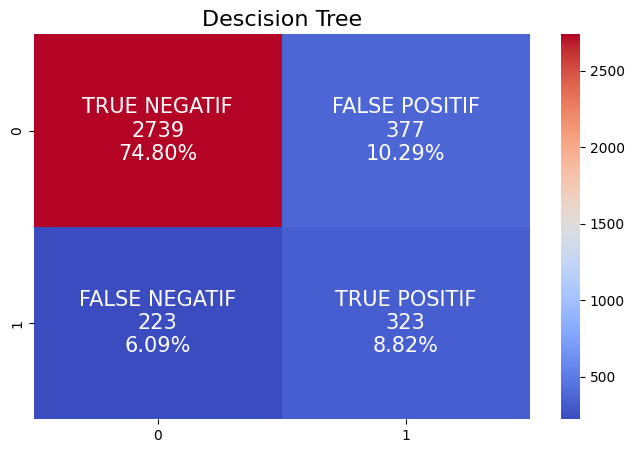

In [ ]:
c_matrix(dt)
plt.title('Descision Tree', fontsize=16)

#### **Hyperparameter Tuning Decision Tree**

In [33]:
# Hyperparameter Tuning

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import uniform
import numpy as np

#list hyperparameters
max_depth = [int(x) for x in np.linspace(1, 110, num = 30)]
min_samples_split = [2,5,10,100]
min_samples_leaf = [1,2,4,10,20,50]
max_features = ['auto','sqrt']
criterion = ['gini','entropy']
splitter = ['best','random']

hyperparameters = dict(max_depth=max_depth,
                       min_samples_split=min_samples_split,
                       min_samples_leaf=min_samples_leaf,
                       max_features=max_features,
                       criterion=criterion,
                       splitter=splitter)

dt = DecisionTreeClassifier(random_state=1)
dt_tuned = GridSearchCV(dt, hyperparameters, cv=5, scoring='precision')
dt_tuned.fit(X_train, y_train)

y_pred = dt_tuned.predict(X_test)
eval_classification(dt_tuned)

Accuracy (Test Set): 0.87
Accuracy (Train Set): 0.89
Precision (Test Set): 0.56
Precision (Train Set): 0.85
Recall (Test Set): 0.72
Recall (Train Set): 0.81
F1-Score (Test Set): 0.63
F1-Score (Train Set): 0.83
roc_auc (test-proba): 0.83
roc_auc (train-proba): 0.94
roc_auc (crossval test): 0.8936823553122917
roc_auc (crossval train): 0.940190780196494


#### **Confussion Matrix Hyperparameter Tuning**

Text(0.5, 1.0, 'Decision Tree - Tuning')

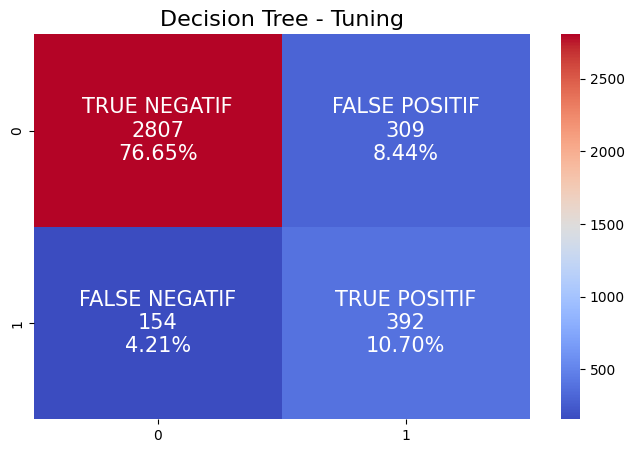

In [34]:
c_matrix(dt_tuned)
plt.title('Decision Tree - Tuning', fontsize=16)

#### **Feature Importance Decision Tree**

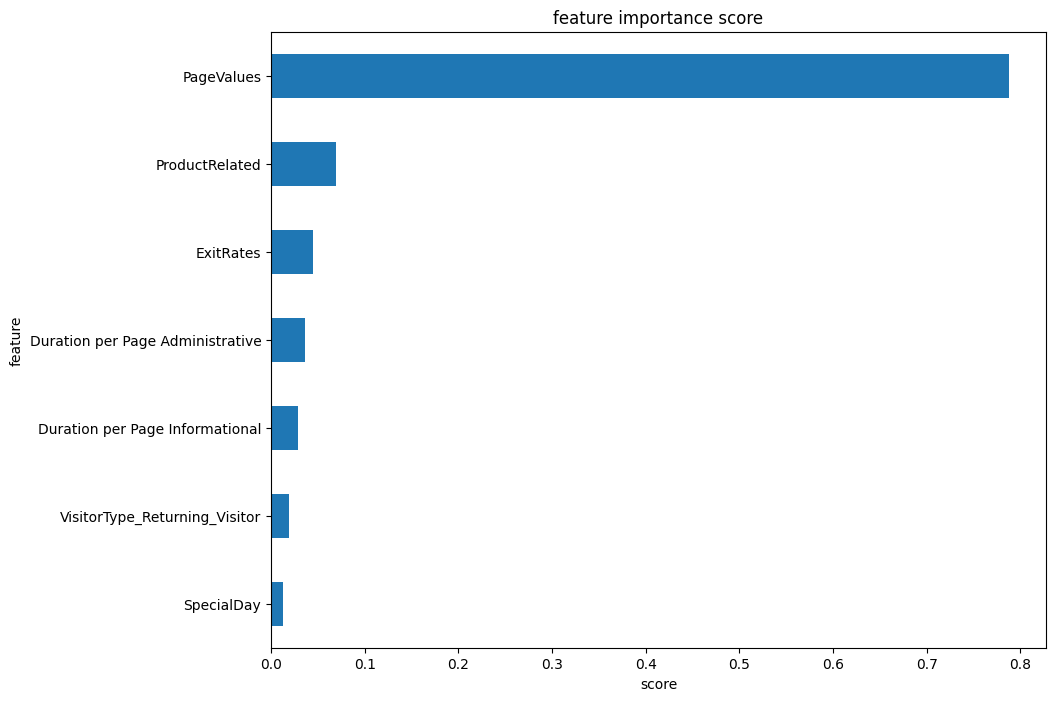

In [35]:
# feature importance
show_feature_importance(dt_tuned.best_estimator_)

### **D ) Random Forest**

#### **Fit Model Random Forest**

In [36]:
# Fit Model Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
eval_classification(rf)

Accuracy (Test Set): 0.88
Accuracy (Train Set): 1.00
Precision (Test Set): 0.57
Precision (Train Set): 1.00
Recall (Test Set): 0.71
Recall (Train Set): 0.99
F1-Score (Test Set): 0.63
F1-Score (Train Set): 1.00
roc_auc (test-proba): 0.90
roc_auc (train-proba): 1.00
roc_auc (crossval test): 0.9520976029891297
roc_auc (crossval train): 0.9991184852343263


Masih terlalu overfitting

#### **Confussion Matrix Random Forest**

Text(0.5, 1.0, 'Random Forest')

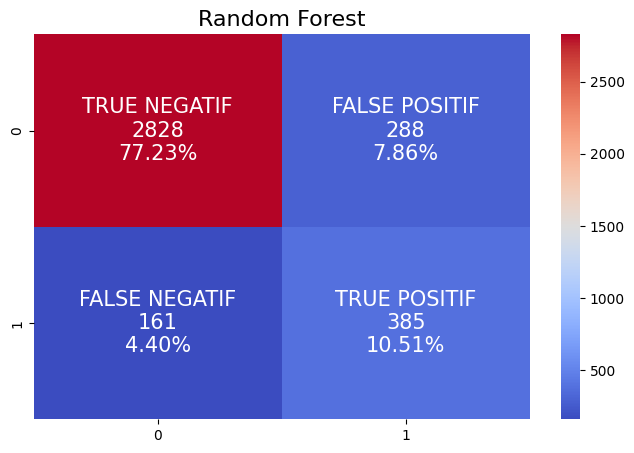

In [37]:
c_matrix(rf)
plt.title('Random Forest', fontsize=16)

#### **Hyperparamete Tuning Random Forest**

In [38]:
# tuning hyperparameter RF + oversampling
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

n_estimators = [int(x) for x in np.linspace(125, 200, 15)]
criterion = ['gini', 'entropy']
max_depth = [int(x) for x in np.arange(3, 5)]
min_samples_split = [int(x) for x in np.linspace(1000, 1200 ,20)]
min_samples_leaf = [int(x) for x in np.linspace(200, 300, 20)] # min_samples_leaf
hyperparameters = dict(n_estimators=n_estimators, criterion=criterion, max_depth=max_depth,
                       min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf)

rf = RandomForestClassifier(random_state=42)
rf_tuned = RandomizedSearchCV(rf, hyperparameters, cv=5, scoring = 'roc_auc')
rf_tuned.fit(X_train, y_train)
eval_classification(rf_tuned)

Accuracy (Test Set): 0.87
Accuracy (Train Set): 0.86
Precision (Test Set): 0.54
Precision (Train Set): 0.78
Recall (Test Set): 0.79
Recall (Train Set): 0.79
F1-Score (Test Set): 0.64
F1-Score (Train Set): 0.79
roc_auc (test-proba): 0.90
roc_auc (train-proba): 0.91
roc_auc (crossval test): 0.9017183254238883
roc_auc (crossval train): 0.905883159517521


#### **Confussion Matrix Hyperparameter Tuning Random Forest**

Text(0.5, 1.0, 'Random Forest - Tuning')

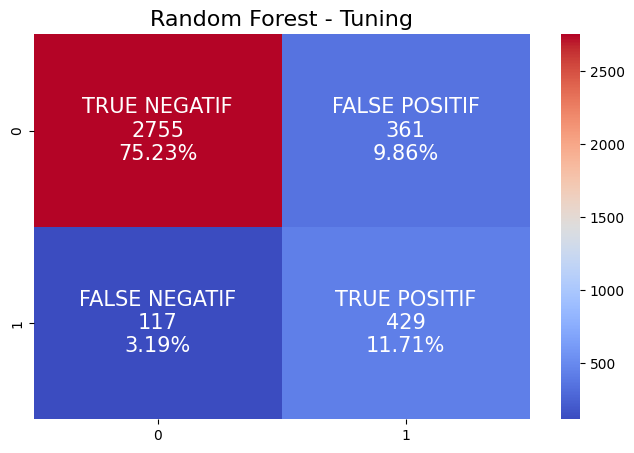

In [39]:
c_matrix(rf_tuned)
plt.title('Random Forest - Tuning', fontsize=16)

#### **Feature Importance Random Forest**

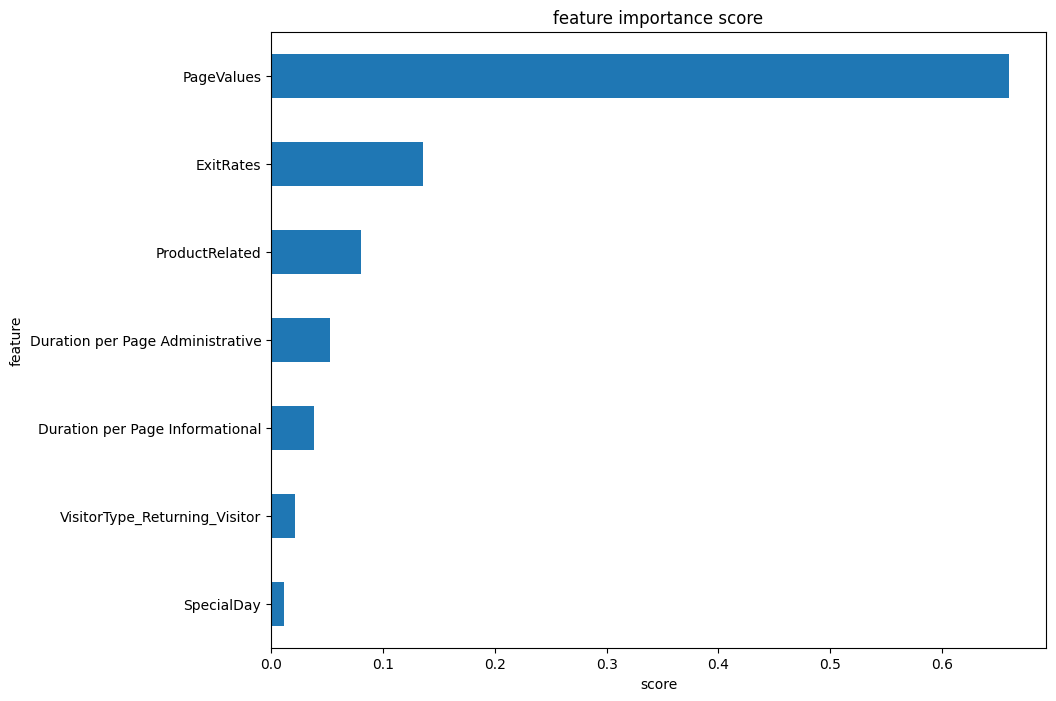

In [40]:
show_feature_importance(rf_tuned.best_estimator_)

#### **Learning Curve Random Forest**

param value: 125; train: 0.9051336531445755; test: 0.8947430137256838
param value: 130; train: 0.907546977690664; test: 0.8948940714826465
param value: 135; train: 0.9051477339419755; test: 0.8934963464007111
param value: 141; train: 0.906898291258385; test: 0.8971575867435944
param value: 146; train: 0.9050889475825831; test: 0.8966906007984314
param value: 151; train: 0.9077354004823158; test: 0.8986760992537629
param value: 157; train: 0.908790529325491; test: 0.8983678121194167
param value: 162; train: 0.9075261280250926; test: 0.8976598390911612
param value: 167; train: 0.9077402880318265; test: 0.8994146364974349
param value: 173; train: 0.9056338123778355; test: 0.8946569049264812
param value: 178; train: 0.9080616832022294; test: 0.8977741610122867
param value: 183; train: 0.9064026898589942; test: 0.8947051023430997
param value: 189; train: 0.9074348161874088; test: 0.897581371345813
param value: 194; train: 0.9072711220688764; test: 0.8969536293830261
param value: 200; train:

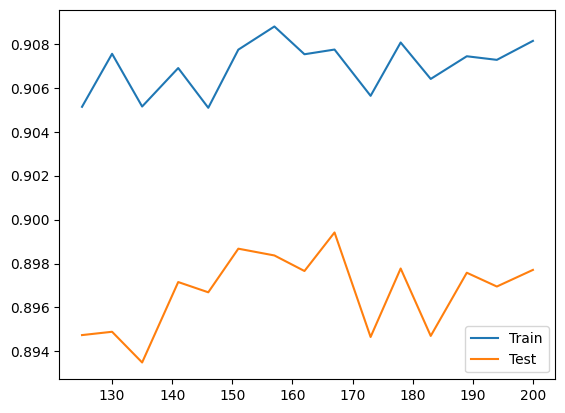

In [41]:
#learning curve
# param_values = [int(x) for x in np.linspace(1, 200, 50)] # n_estimators
# param_values = [int(x) for x in np.linspace(2, 100, 50)] # max_depth
# param_values = [int(x) for x in np.linspace(2, 20, 15)] # min_samples_split
param_values = [int(x) for x in np.linspace(125, 200, 15)] # n_estimators

train_scores = []
test_scores = []

for c in param_values:
    model = RandomForestClassifier(n_estimators = c, max_depth=3)
    model.fit(X_train, y_train)

    # eval on train
    y_pred_train_proba = model.predict_proba(X_train)
    train_auc = roc_auc_score(y_train, y_pred_train_proba[:,1])
    train_scores.append(train_auc)

    # eval on test
    y_pred_proba = model.predict_proba(X_test)
    test_auc = roc_auc_score(y_test, y_pred_proba[:,1])
    test_scores.append(test_auc)

    print('param value: ' + str(c) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc))

plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

### **E ) AdaBoost**

#### **Fit Model AdaBoost**

In [42]:
# Fit Model Adabost

from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
eval_classification(ada)

Accuracy (Test Set): 0.87
Accuracy (Train Set): 0.86
Precision (Test Set): 0.55
Precision (Train Set): 0.79
Recall (Test Set): 0.79
Recall (Train Set): 0.79
F1-Score (Test Set): 0.65
F1-Score (Train Set): 0.79
roc_auc (test-proba): 0.89
roc_auc (train-proba): 0.91
roc_auc (crossval test): 0.9060756335958947
roc_auc (crossval train): 0.9109770653415928


#### **Confussion Matrix AdaBoost**

Text(0.5, 1.0, 'AdaBoost')

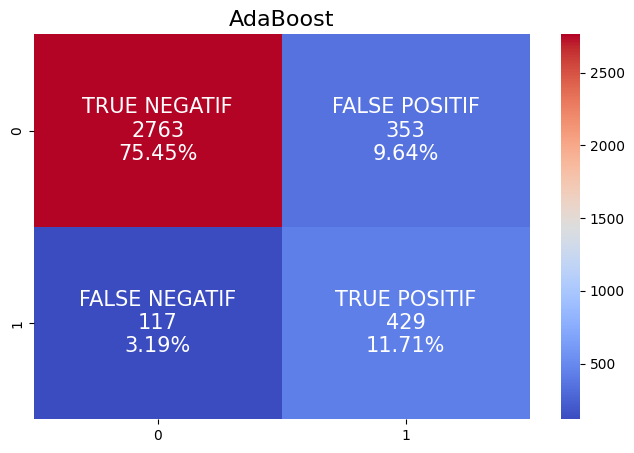

In [43]:
c_matrix(ada)
plt.title('AdaBoost', fontsize=16)

#### **Hyperparameter Tuning AdaBoost**

In [ ]:
# Hyperparameter tuning

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import numpy as np

# List of hyperparameter
hyperparameters = dict(n_estimators = [int(x) for x in np.linspace(start = 50, stop = 2000, num = 2000)], # Jumlah iterasi
                       learning_rate = [float(x) for x in np.linspace(start = 0.001, stop = 0.1, num = 200)],  
                       algorithm = ['SAMME', 'SAMME.R']
                      )

# Init model
ada = AdaBoostClassifier(random_state=42)
ada_tuned = RandomizedSearchCV(ada, hyperparameters, random_state=42, cv=5, scoring='recall')
ada_tuned.fit(X_train,y_train)

# Predict & Evaluation
eval_classification(ada_tuned)

Accuracy (Test Set): 0.87
Accuracy (Train Set): 0.86
Precision (Test Set): 0.54
Precision (Train Set): 0.78
Recall (Test Set): 0.80
Recall (Train Set): 0.80
F1-Score (Test Set): 0.65
F1-Score (Train Set): 0.79
roc_auc (test-proba): 0.88
roc_auc (train-proba): 0.88


#### **Confussion Matrix Hyperparameter Tuning AdaBoost**

Text(0.5, 1.0, 'AdaBoost - Tuning')

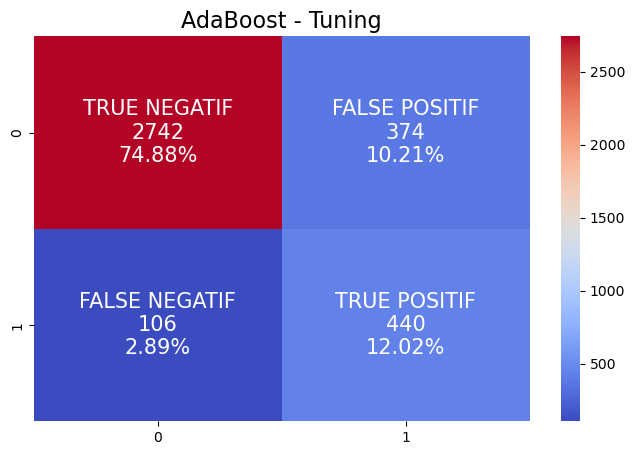

In [ ]:
c_matrix(ada_tuned)
plt.title('AdaBoost - Tuning', fontsize=16)

#### **Feature Importance**

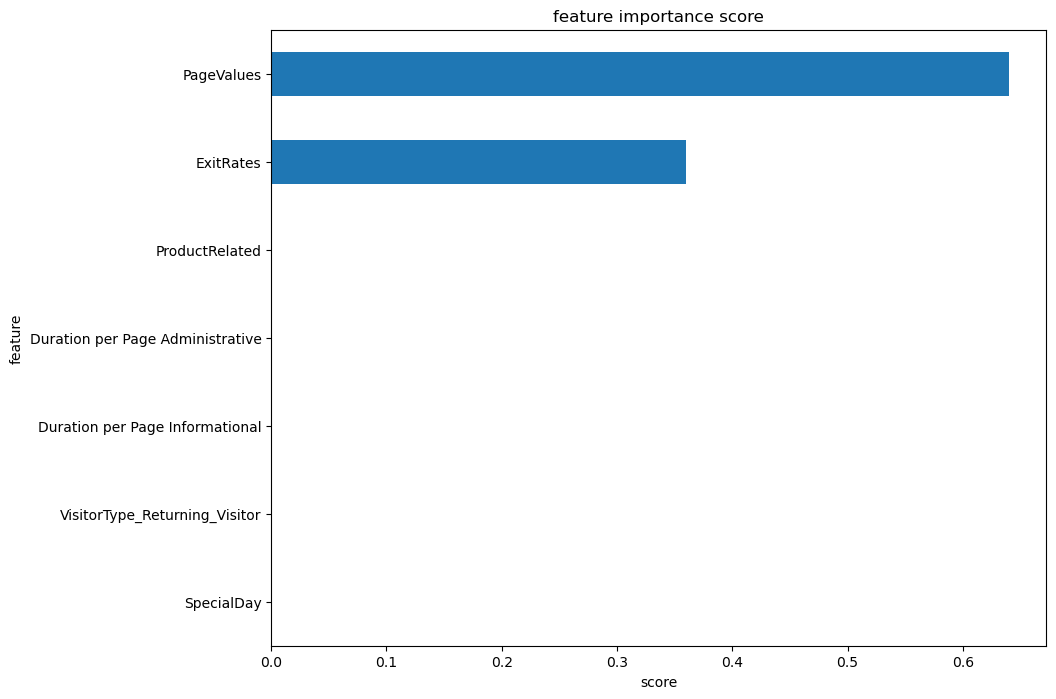

In [ ]:
show_feature_importance(ada_tuned.best_estimator_)

### **F ) XgBoost**

#### **Fit Model XgBoost**

In [ ]:
import sys
!{sys.executable} -m pip install xgboost
# Fit Model XgBoost
from xgboost import XGBClassifier

xg = XGBClassifier()
xg.fit(X_train, y_train)
eval_classification(xg)

Accuracy (Test Set): 0.88
Accuracy (Train Set): 0.96
Precision (Test Set): 0.58
Precision (Train Set): 0.95
Recall (Test Set): 0.68
Recall (Train Set): 0.91
F1-Score (Test Set): 0.63
F1-Score (Train Set): 0.93
roc_auc (test-proba): 0.90
roc_auc (train-proba): 0.99
roc_auc (crossval test): 0.9438873891435415
roc_auc (crossval train): 0.9898115197555606


#### **Confussion Matrix XgBoost**

Text(0.5, 1.0, 'XGBoost - Tuning')

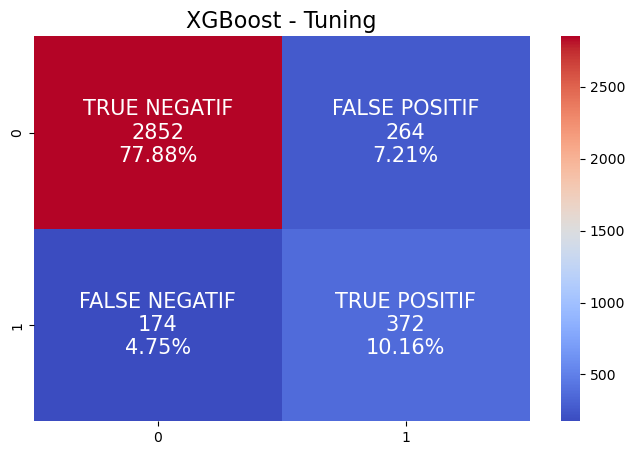

In [ ]:
c_matrix(xg)
plt.title('XGBoost - Tuning', fontsize=16)

#### **Hyperparameter tuning XgBoost**

In [ ]:
# Hiperparameter tuning

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import numpy as np

#Menjadikan ke dalam bentuk dictionary
hyperparameters = {
                    'max_depth' : [int(x) for x in np.linspace(10, 110, num = 11)],
                    'min_child_weight' : [int(x) for x in np.linspace(1, 20, num = 11)],
                    'gamma' : [float(x) for x in np.linspace(0, 1, num = 11)],
                    'tree_method' : ['auto', 'exact', 'approx', 'hist'],

                    'colsample_bytree' : [float(x) for x in np.linspace(0, 1, num = 11)],
                    'eta' : [float(x) for x in np.linspace(0, 1, num = 100)],

                    'lambda' : [float(x) for x in np.linspace(0, 1, num = 11)],
                    'alpha' : [float(x) for x in np.linspace(0, 1, num = 11)]
                    }

# Init
from xgboost import XGBClassifier
xg = XGBClassifier(random_state=42)
xg_tuned = RandomizedSearchCV(xg, hyperparameters, cv=5, random_state=42, scoring='recall')
xg_tuned.fit(X_train,y_train)

# Predict & Evaluation
eval_classification(xg_tuned)

Accuracy (Test Set): 0.87
Accuracy (Train Set): 0.98
Precision (Test Set): 0.55
Precision (Train Set): 0.99
Recall (Test Set): 0.62
Recall (Train Set): 0.96
F1-Score (Test Set): 0.59
F1-Score (Train Set): 0.98
roc_auc (test-proba): 0.87
roc_auc (train-proba): 1.00
roc_auc (crossval test): 0.9389123120524451
roc_auc (crossval train): 0.9959975525531682


#### **Confussion Matrix Hyperparameter Tuning XgBoost**

Text(0.5, 1.0, 'XGBoost - Tuning')

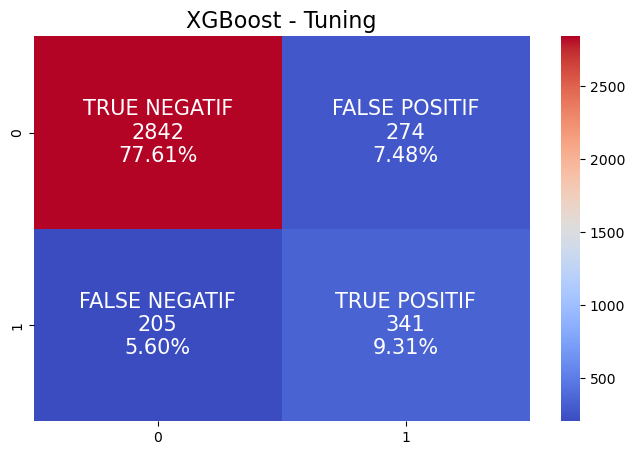

In [ ]:
c_matrix(xg_tuned)
plt.title('XGBoost - Tuning', fontsize=16)

#### **Feature Importance**

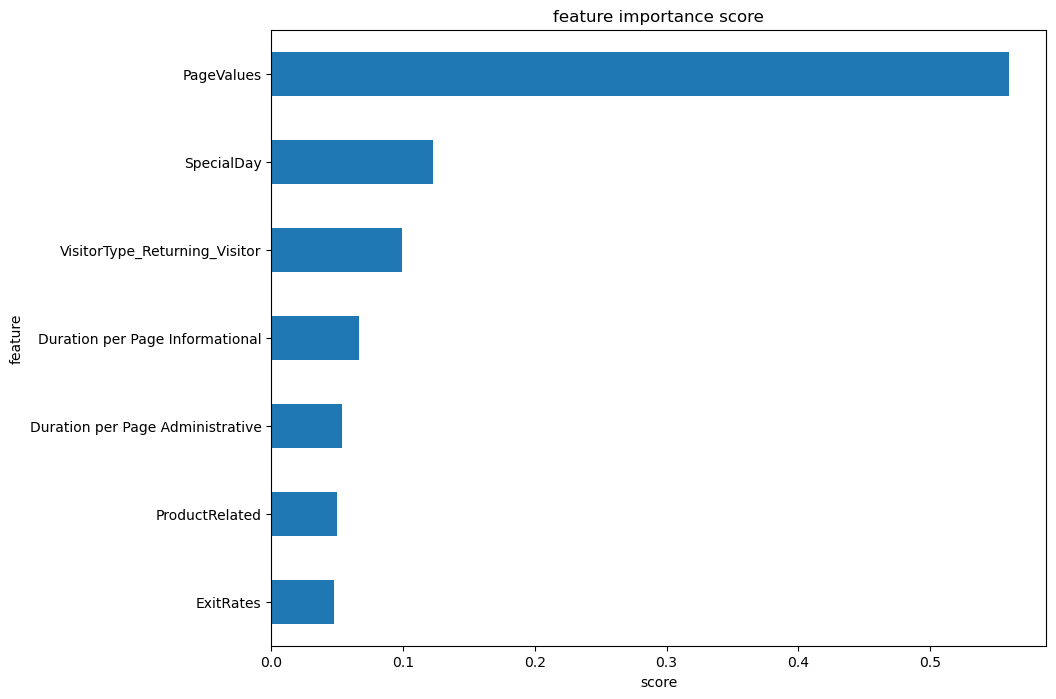

In [ ]:
show_feature_importance(xg_tuned.best_estimator_)

## **3. Shape Value Model Random Forest**
---

From the comparison of the train-test evaluation matrices across several modeling algorithms, the Random Forest model with hyperparameter tuning was selected for implementation, achieving an ROC AUC of 0.90. This metric indicates that the model performs well in distinguishing customers who are predicted to make a purchase from those who are not in the e-commerce setting.

In [ ]:
%pip install shap

In [ ]:
import sys
!{sys.executable} -m pip install shap
import shap

model = RandomForestClassifier(n_estimators=125, max_depth=4)
model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

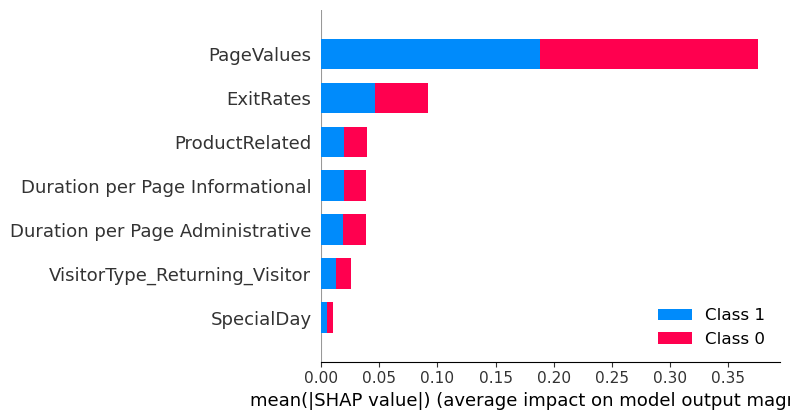

In [ ]:
# bar
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, plot_type='bar')

The following shows the ranking of features **(feature importance)** from the most influential to the least influential in the prediction model. This chart is based on **absolute SHAP values**, meaning it does not matter whether a feature affects the prediction positively or negatively. The three most influential features are **PageValues, ExitRates, and ProductRelated.**

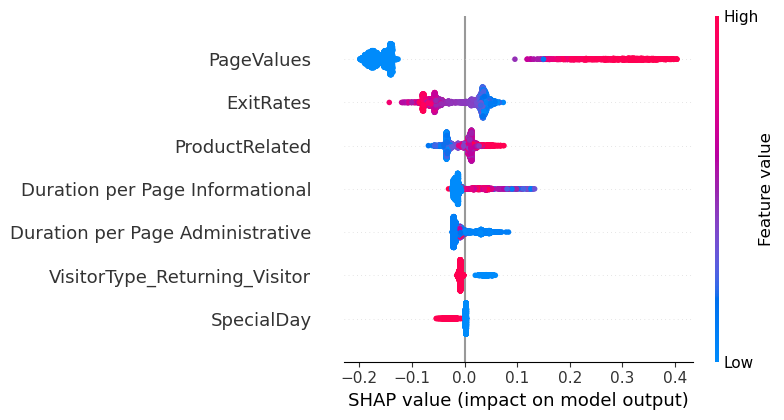

In [ ]:
# beeswarm
shap.summary_plot(shap_values[1], X_test) 

The beeswarm plot shows how higher or lower values of each feature influence the prediction results. For the three most important features, PageValues and ProductRelated with higher values have a positive impact on the prediction (positively correlated with the target). It can be interpreted that the higher the values of PageValues and ProductRelated, the greater the model’s tendency to predict a positive target (visitors who make a purchase).

In contrast, **ExitRates with higher values have a negative impact on the prediction** (negatively correlated with the target). Therefore,** the lower the ExitRates value, the greater the likelihood that the model will predict a visitor who makes a purchase**.